# Quasi-Experimental Methods for Causal Inference

**Notebook NB03b: Complementary Methods to A/B Testing**

Date: 2026-04-05

## Why This Matters

In the real world—especially in healthcare—we often **cannot randomly assign** people (or hospitals) to treatment and control groups. A hospital can't be forced to use an AI diagnostic tool, and an insurance company won't deny claims to half their patients just for an experiment.

This notebook covers three powerful methods that estimate **causal effects WITHOUT randomization**:

1. **Difference-in-Differences (DiD)**: Compare how two groups trend over time, before and after treatment
2. **Regression Discontinuity Design (RDD)**: Exploit natural thresholds (e.g., eligibility cutoffs) to find causation
3. **Sample Size & Power Analysis**: Design experiments with the right number of observations before you start

These methods are essential in **healthcare, policy, and any domain where randomization is infeasible or unethical**. They're also great interview talking points—they show you understand when A/B tests aren't the answer.

### Example Context: SmarterDx

SmarterDx (our fictional AI diagnostic company) cannot randomly force hospitals to adopt their AI. Instead:
- **Some hospitals adopt in Q2, others in Q4** → use DiD to estimate the AI's impact
- **Rollout prioritizes larger hospitals (200+ beds)** → use RDD to compare hospitals just above/below that cutoff
- **Before launching regionally, pilot at 50 sites** → power analysis tells us if 50 is enough to detect a real improvement

---

In [1]:
# Standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')
import os

# Random seed for reproducibility
np.random.seed(42)

# Color palette
colors = {
    'primary': '#2E86AB',
    'secondary': '#F18F01',
    'tertiary': '#2CA58D',
    'accent': '#E15554'
}

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Create output directory
output_dir = '../data/outputs/nb04/'
os.makedirs(output_dir, exist_ok=True)
print(f'Output directory ready: {output_dir}')

Output directory ready: ../data/outputs/nb04/


## 1. Difference-in-Differences (DiD)

### The Core Idea

Imagine you have **two groups of hospitals**:
- **Group A (Treatment)**: Starts using SmarterDx AI in Month 6
- **Group B (Control)**: Does NOT adopt the AI (yet)

You measure both groups **before AND after** the adoption date. The magic of DiD is this:

**Treatment Effect = (Post − Pre in Group A) − (Post − Pre in Group B)**

In plain English: *How much did Group A improve relative to Group B?*

### Why It Works

Both groups might naturally have upward trends (hospitals improve naturally over time). But by comparing the *change in trends* between groups, we isolate the causal effect of the treatment.

### Key Assumption: Parallel Trends

For DiD to give us a causal estimate, we need **parallel trends**: absent the treatment, both groups would have followed the same trajectory. We can't test this directly for post-treatment periods, but we can check if pre-treatment trends are parallel.

### When to Use DiD

- Staggered product rollouts (some users/sites adopt first, others later)
- Policy changes that affect some regions but not others
- Natural events that impact groups differently
- Any setting where you have **before/after data for treatment and control groups**

### Benefits & Limitations

**Strengths:**
- No randomization needed
- Intuitive visual story (easy to present to non-technical stakeholders)
- Accounts for time trends and group-level differences
- Widely accepted in health economics and policy research

**Limitations:**
- Parallel trends assumption is **untestable** (can only check pre-trends)
- Sensitive to model specification and confounders
- Doesn't handle time-varying confounders well
- Requires sufficient pre-period data to verify trends

---

In [2]:
# Generate synthetic DiD dataset
# Scenario: 20 hospitals, 12 months of data
# 10 hospitals adopt AI at month 6 (treatment), 10 don't (control)

np.random.seed(42)

n_hospitals = 20
n_months = 12
treatment_month = 6  # Adoption happens at month 6

# Create base dataset
data = []
for h in range(n_hospitals):
    treated = 1 if h < 10 else 0  # First 10 are treatment group
    for m in range(1, n_months + 1):
        post = 1 if m > treatment_month else 0
        
        # Outcome: diagnoses captured per month
        # Base: 50 diagnoses
        # Trend: +2 per month for everyone
        # Treatment effect: +8 additional diagnoses in post-period if treated
        # Noise: random variation
        trend_effect = 2 * m
        treatment_effect = 8 * treated * post
        noise = np.random.normal(0, 3)
        outcome = 50 + trend_effect + treatment_effect + noise
        
        data.append({
            'hospital_id': h,
            'month': m,
            'treated': treated,
            'post': post,
            'diagnoses_captured': max(outcome, 0)  # No negative diagnoses
        })

df_did = pd.DataFrame(data)
print('DiD Dataset Summary:')
print(f'Shape: {df_did.shape}')
print(f'\nFirst few rows:')
print(df_did.head(10))
print(f'\nSummary stats by group:')
print(df_did.groupby('treated')['diagnoses_captured'].describe())

DiD Dataset Summary:
Shape: (240, 5)

First few rows:
   hospital_id  month  treated  post  diagnoses_captured
0            0      1        1     0           53.490142
1            0      2        1     0           53.585207
2            0      3        1     0           57.943066
3            0      4        1     0           62.569090
4            0      5        1     0           59.297540
5            0      6        1     0           61.297589
6            0      7        1     1           76.737638
7            0      8        1     1           76.302304
8            0      9        1     1           74.591577
9            0     10        1     1           79.627680

Summary stats by group:
         count       mean        std        min        25%        50%  \
treated                                                                 
0        120.0  63.223093   7.944078  47.866992  56.489208  63.280704   
1        120.0  66.762493  11.308788  48.120990  56.932318  68.656611   

 

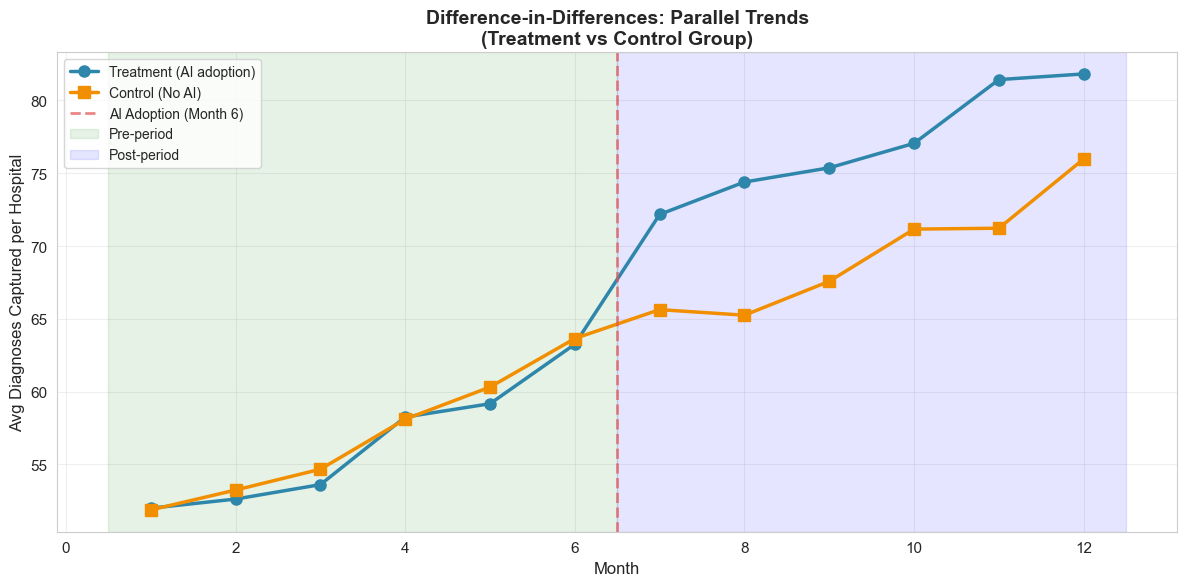

Visualization saved: did_parallel_trends.png


In [3]:
# Visualize the parallel trends assumption
fig, ax = plt.subplots(figsize=(12, 6))

# Calculate mean outcome by month and treatment status
did_means = df_did.groupby(['month', 'treated'])['diagnoses_captured'].mean().reset_index()

# Plot trends
treatment_data = did_means[did_means['treated'] == 1]
control_data = did_means[did_means['treated'] == 0]

ax.plot(treatment_data['month'], treatment_data['diagnoses_captured'], 
        marker='o', linewidth=2.5, markersize=8, 
        label='Treatment (AI adoption)', color=colors['primary'])
ax.plot(control_data['month'], control_data['diagnoses_captured'],
        marker='s', linewidth=2.5, markersize=8,
        label='Control (No AI)', color=colors['secondary'])

# Add vertical line at treatment time
ax.axvline(x=treatment_month + 0.5, color=colors['accent'], linestyle='--', 
           linewidth=2, label='AI Adoption (Month 6)', alpha=0.7)

# Shade pre and post periods
ax.axvspan(0.5, treatment_month + 0.5, alpha=0.1, color='green', label='Pre-period')
ax.axvspan(treatment_month + 0.5, n_months + 0.5, alpha=0.1, color='blue', label='Post-period')

ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Avg Diagnoses Captured per Hospital', fontsize=12)
ax.set_title('Difference-in-Differences: Parallel Trends\n(Treatment vs Control Group)', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{output_dir}did_parallel_trends.png', dpi=300, bbox_inches='tight')
plt.show()

print('Visualization saved: did_parallel_trends.png')

In [4]:
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from pathlib import Path

# Recreate parallel trends plot as interactive Plotly
fig = go.Figure()

# Add treatment group line
treatment_data_py = did_means[did_means['treated'] == 1]
fig.add_trace(go.Scatter(
    x=treatment_data_py['month'],
    y=treatment_data_py['diagnoses_captured'],
    mode='lines+markers',
    name='Treatment (AI adoption)',
    line=dict(color=colors['primary'], width=2.5),
    marker=dict(size=8)
))

# Add control group line
control_data_py = did_means[did_means['treated'] == 0]
fig.add_trace(go.Scatter(
    x=control_data_py['month'],
    y=control_data_py['diagnoses_captured'],
    mode='lines+markers',
    name='Control (No AI)',
    line=dict(color=colors['secondary'], width=2.5),
    marker=dict(size=8, symbol='square')
))

# Add treatment period shading
fig.add_vrect(x0=0.5, x1=treatment_month + 0.5, fillcolor='green', opacity=0.1, layer='below', line_width=0)
fig.add_vrect(x0=treatment_month + 0.5, x1=n_months + 0.5, fillcolor='blue', opacity=0.1, layer='below', line_width=0)

# Add vertical line at treatment time
fig.add_vline(x=treatment_month + 0.5, line_dash='dash', line_color=colors['accent'], line_width=2, annotation_text='AI Adoption (Month 6)')

fig.update_layout(
    title='Difference-in-Differences: Parallel Trends<br>(Treatment vs Control Group)',
    xaxis_title='Month',
    yaxis_title='Avg Diagnoses Captured per Hospital',
    hovermode='x unified',
    height=600,
    template='plotly_white'
)

DATA_OUTPUT = Path('../data/outputs/nb03/')
fig.write_html(str(DATA_OUTPUT / 'nb04_did_parallel_trends_interactive.html'), include_plotlyjs='cdn')
print('Saved: nb04_did_parallel_trends_interactive.html')

Saved: nb04_did_parallel_trends_interactive.html


In [5]:
# Estimate DiD effect using OLS regression
# Model: y = β0 + β1*treated + β2*post + β3*(treated*post) + ε
# β3 (the interaction term) is our DiD estimate

# Create interaction term
df_did['treated_x_post'] = df_did['treated'] * df_did['post']

# Prepare regression
X = df_did[['treated', 'post', 'treated_x_post']]
X = sm.add_constant(X)
y = df_did['diagnoses_captured']

# Fit OLS
did_model = sm.OLS(y, X).fit()
print(did_model.summary())

# Extract DiD estimate (coefficient on treated*post)
did_estimate = did_model.params['treated_x_post']
did_se = did_model.bse['treated_x_post']
did_ci = did_model.conf_int().loc['treated_x_post']

print(f'\n=== DiD ESTIMATE ===')
print(f'Treatment Effect (β3): {did_estimate:.3f} diagnoses')
print(f'Standard Error: {did_se:.3f}')
print(f'95% CI: [{did_ci[0]:.3f}, {did_ci[1]:.3f}]')
print(f'p-value: {did_model.pvalues["treated_x_post"]:.4f}')
print(f'\nInterpretation:')
print(f'Adopting the AI is associated with an increase of {did_estimate:.1f} diagnoses')
print(f'per hospital per month, after controlling for pre-existing trends and group differences.')

                            OLS Regression Results                            
Dep. Variable:     diagnoses_captured   R-squared:                       0.771
Model:                            OLS   Adj. R-squared:                  0.769
Method:                 Least Squares   F-statistic:                     265.6
Date:                Sun, 05 Apr 2026   Prob (F-statistic):           2.45e-75
Time:                        16:20:31   Log-Likelihood:                -713.41
No. Observations:                 240   AIC:                             1435.
Df Residuals:                     236   BIC:                             1449.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             56.9752      0.616     92.

In [6]:
# Test the parallel trends assumption using pre-period data only
# If trends are parallel in the pre-period, the interaction term should be non-significant

df_pre = df_did[df_did['post'] == 0].copy()

# Create an interaction term for month*treated in pre-period
df_pre['month_x_treated'] = df_pre['month'] * df_pre['treated']

X_pre = df_pre[['treated', 'month', 'month_x_treated']]
X_pre = sm.add_constant(X_pre)
y_pre = df_pre['diagnoses_captured']

pre_model = sm.OLS(y_pre, X_pre).fit()
print('Pre-Period Parallel Trends Test:')
print(pre_model.summary())

interaction_p = pre_model.pvalues['month_x_treated']
print(f'\n=== PARALLEL TRENDS TEST ===')
print(f'Interaction (month × treated) p-value: {interaction_p:.4f}')
if interaction_p > 0.05:
    print('✓ Non-significant: Parallel trends assumption appears SATISFIED')
else:
    print('✗ Significant: Parallel trends assumption may be VIOLATED')

Pre-Period Parallel Trends Test:
                            OLS Regression Results                            
Dep. Variable:     diagnoses_captured   R-squared:                       0.655
Model:                            OLS   Adj. R-squared:                  0.646
Method:                 Least Squares   F-statistic:                     73.46
Date:                Sun, 05 Apr 2026   Prob (F-statistic):           1.07e-26
Time:                        16:20:32   Log-Likelihood:                -298.48
No. Observations:                 120   AIC:                             605.0
Df Residuals:                     116   BIC:                             616.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const    

## 2. Regression Discontinuity Design (RDD)

### The Core Idea

Imagine SmarterDx decides: **"We'll prioritize hospitals with 200+ beds first."**

- Hospitals with **199 beds** → don't get AI yet
- Hospitals with **201 beds** → get AI immediately

These hospitals are almost identical—just a couple of beds difference. But one gets the treatment and one doesn't. **At the cutoff, treatment assignment is nearly random**, so we can estimate a causal effect by comparing just-above and just-below the threshold.

### Why It Works

Hospitals on either side of the cutoff (bed count) are likely similar in all other ways. Any sharp jump in outcomes at the cutoff is likely due to the treatment, not confounding.

### Key Insight: Local Randomization

RDD exploits the fact that **near the cutoff, treatment assignment acts like a randomized experiment**. The "running variable" (bed count) determines eligibility, and we can't game it precisely.

### When to Use RDD

- Eligibility based on a clear cutoff or threshold
- Examples: age limits, income thresholds, test scores, performance metrics
- Policy changes with explicit rules (e.g., "subsidies for hospitals <100 beds")
- Any setting with a **continuous running variable and sharp eligibility rule**

### Benefits & Limitations

**Strengths:**
- Strong causal identification near the cutoff
- Visually compelling (easy to show the "jump")
- Minimal assumptions compared to other quasi-experimental methods
- Natural experiments are ethical (no one is harmed)

**Limitations:**
- Only estimates effect **AT the cutoff**, not for everyone
- Requires a clear, objective cutoff (people can't "game" it)
- Sensitive to **bandwidth choice** (which hospitals count as "near" the cutoff?)
- Needs many observations near the cutoff for precise estimates
- Can fail if people manipulate the running variable (e.g., hospitals adding beds to cross threshold)

---

In [7]:
# Generate synthetic RDD dataset
# Scenario: 200 hospitals with varying bed counts
# Treatment: hospitals with bed_count >= 200 get the AI
# Outcome: revenue uplift from AI

np.random.seed(42)

n_hospitals_rdd = 200
cutoff = 200  # Hospitals with 200+ beds get treatment

# Running variable: bed count (50-400)
bed_counts = np.random.uniform(50, 400, n_hospitals_rdd)

# Treatment assignment
treated_rdd = (bed_counts >= cutoff).astype(int)

# Outcome: revenue uplift (%)
# Base relationship with bed count (more beds = more revenue naturally)
base_effect = 0.3 * bed_counts  # $0.3M per bed
# Jump at cutoff: treatment effect
treatment_jump = 50 * treated_rdd  # $50M uplift from AI
# Noise
noise_rdd = np.random.normal(0, 15, n_hospitals_rdd)

revenue_uplift = base_effect + treatment_jump + noise_rdd

df_rdd = pd.DataFrame({
    'bed_count': bed_counts,
    'treated': treated_rdd,
    'revenue_uplift_millions': revenue_uplift
})

print('RDD Dataset Summary:')
print(f'Shape: {df_rdd.shape}')
print(f'\nTreatment group summary (bed_count >= 200):')
print(df_rdd[df_rdd['treated'] == 1][['bed_count', 'revenue_uplift_millions']].describe())
print(f'\nControl group summary (bed_count < 200):')
print(df_rdd[df_rdd['treated'] == 0][['bed_count', 'revenue_uplift_millions']].describe())

RDD Dataset Summary:
Shape: (200, 3)

Treatment group summary (bed_count >= 200):
        bed_count  revenue_uplift_millions
count  106.000000               106.000000
mean   304.451534               142.450588
std     55.961811                21.118830
min    201.180757                97.011511
25%    259.331362               127.362145
50%    305.257336               144.809765
75%    356.554382               157.162947
max    395.410428               187.658271

Control group summary (bed_count < 200):
        bed_count  revenue_uplift_millions
count   94.000000                94.000000
mean   123.495465                37.942675
std     41.439013                19.044079
min     51.932741                -3.195108
25%     88.817563                25.990677
50%    126.028211                34.736928
75%    159.035111                50.114124
max    199.639356                93.369173


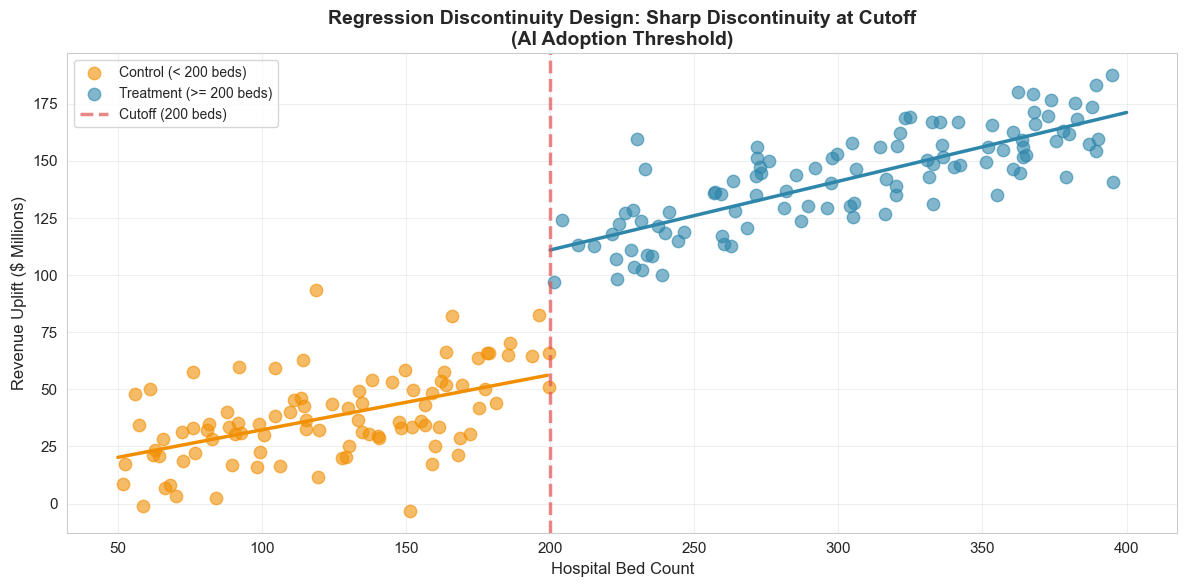

Visualization saved: rdd_discontinuity.png


In [8]:
# Visualize the RDD discontinuity
fig, ax = plt.subplots(figsize=(12, 6))

# Separate treated and control
control_rdd = df_rdd[df_rdd['treated'] == 0]
treated_rdd_group = df_rdd[df_rdd['treated'] == 1]

# Scatter plot
ax.scatter(control_rdd['bed_count'], control_rdd['revenue_uplift_millions'],
          alpha=0.6, s=80, color=colors['secondary'], label='Control (< 200 beds)')
ax.scatter(treated_rdd_group['bed_count'], treated_rdd_group['revenue_uplift_millions'],
          alpha=0.6, s=80, color=colors['primary'], label='Treatment (>= 200 beds)')

# Fit separate lines on each side of cutoff
# Control side
X_control = control_rdd['bed_count'].values.reshape(-1, 1)
y_control = control_rdd['revenue_uplift_millions'].values
lr_control = LinearRegression().fit(X_control, y_control)
x_line_control = np.linspace(50, 199, 100).reshape(-1, 1)
y_line_control = lr_control.predict(x_line_control)
ax.plot(x_line_control, y_line_control, linewidth=2.5, color=colors['secondary'], linestyle='-')

# Treatment side
X_treated = treated_rdd_group['bed_count'].values.reshape(-1, 1)
y_treated = treated_rdd_group['revenue_uplift_millions'].values
lr_treated = LinearRegression().fit(X_treated, y_treated)
x_line_treated = np.linspace(200, 400, 100).reshape(-1, 1)
y_line_treated = lr_treated.predict(x_line_treated)
ax.plot(x_line_treated, y_line_treated, linewidth=2.5, color=colors['primary'], linestyle='-')

# Cutoff line
ax.axvline(x=cutoff, color=colors['accent'], linestyle='--', linewidth=2.5, 
          label=f'Cutoff (200 beds)', alpha=0.7)

ax.set_xlabel('Hospital Bed Count', fontsize=12)
ax.set_ylabel('Revenue Uplift ($ Millions)', fontsize=12)
ax.set_title('Regression Discontinuity Design: Sharp Discontinuity at Cutoff\n(AI Adoption Threshold)', 
            fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{output_dir}rdd_discontinuity.png', dpi=300, bbox_inches='tight')
plt.show()

print('Visualization saved: rdd_discontinuity.png')

In [9]:
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from pathlib import Path

# Recreate RDD discontinuity plot as interactive Plotly
fig = go.Figure()

# Control scatter
control_rdd_py = df_rdd[df_rdd['treated'] == 0]
fig.add_trace(go.Scatter(
    x=control_rdd_py['bed_count'],
    y=control_rdd_py['revenue_uplift_millions'],
    mode='markers',
    name='Control (< 200 beds)',
    marker=dict(size=8, color=colors['secondary'], opacity=0.6)
))

# Treatment scatter
treated_rdd_py = df_rdd[df_rdd['treated'] == 1]
fig.add_trace(go.Scatter(
    x=treated_rdd_py['bed_count'],
    y=treated_rdd_py['revenue_uplift_millions'],
    mode='markers',
    name='Treatment (>= 200 beds)',
    marker=dict(size=8, color=colors['primary'], opacity=0.6)
))

# Regression lines
from sklearn.linear_model import LinearRegression
X_control_py = control_rdd_py['bed_count'].values.reshape(-1, 1)
y_control_py = control_rdd_py['revenue_uplift_millions'].values
lr_control_py = LinearRegression().fit(X_control_py, y_control_py)
x_line_control_py = np.linspace(50, 199, 100)
y_line_control_py = lr_control_py.predict(x_line_control_py.reshape(-1, 1))
fig.add_trace(go.Scatter(x=x_line_control_py, y=y_line_control_py, mode='lines', name='Control fit', line=dict(color=colors['secondary'], width=2.5)))

X_treated_py = treated_rdd_py['bed_count'].values.reshape(-1, 1)
y_treated_py = treated_rdd_py['revenue_uplift_millions'].values
lr_treated_py = LinearRegression().fit(X_treated_py, y_treated_py)
x_line_treated_py = np.linspace(200, 400, 100)
y_line_treated_py = lr_treated_py.predict(x_line_treated_py.reshape(-1, 1))
fig.add_trace(go.Scatter(x=x_line_treated_py, y=y_line_treated_py, mode='lines', name='Treatment fit', line=dict(color=colors['primary'], width=2.5)))

# Add cutoff line
fig.add_vline(x=cutoff, line_dash='dash', line_color=colors['accent'], line_width=2.5, annotation_text='Cutoff (200 beds)')

fig.update_layout(
    title='Regression Discontinuity Design: Sharp Discontinuity at Cutoff<br>(AI Adoption Threshold)',
    xaxis_title='Hospital Bed Count',
    yaxis_title='Revenue Uplift ($ Millions)',
    hovermode='closest',
    height=600,
    template='plotly_white'
)

DATA_OUTPUT = Path('../data/outputs/nb03/')
fig.write_html(str(DATA_OUTPUT / 'nb04_rdd_discontinuity_interactive.html'), include_plotlyjs='cdn')
print('Saved: nb04_rdd_discontinuity_interactive.html')

Saved: nb04_rdd_discontinuity_interactive.html


In [10]:
# Estimate RDD effect using local linear regression
# Filter to bandwidth around cutoff, then fit separate slopes

bandwidth = 50  # Include hospitals 150-250 beds

df_rdd_local = df_rdd[
    (df_rdd['bed_count'] >= cutoff - bandwidth) & 
    (df_rdd['bed_count'] <= cutoff + bandwidth)
].copy()

# Center the running variable at the cutoff
df_rdd_local['bed_count_centered'] = df_rdd_local['bed_count'] - cutoff

# Create interaction: centered bed count × treated
df_rdd_local['bed_centered_x_treated'] = df_rdd_local['bed_count_centered'] * df_rdd_local['treated']

# Fit local linear regression
# y = β0 + β1*bed_centered + β2*treated + β3*(bed_centered*treated) + ε
X_local = df_rdd_local[['bed_count_centered', 'treated', 'bed_centered_x_treated']]
X_local = sm.add_constant(X_local)
y_local = df_rdd_local['revenue_uplift_millions']

rdd_model = sm.OLS(y_local, X_local).fit()
print(rdd_model.summary())

# Extract RDD estimate (coefficient on treated)
rdd_estimate = rdd_model.params['treated']
rdd_se = rdd_model.bse['treated']
rdd_ci = rdd_model.conf_int().loc['treated']

print(f'\n=== RDD ESTIMATE (Bandwidth = {bandwidth} beds) ===')
print(f'Treatment Effect (at cutoff): ${rdd_estimate:.2f}M')
print(f'Standard Error: ${rdd_se:.2f}M')
print(f'95% CI: [${rdd_ci[0]:.2f}M, ${rdd_ci[1]:.2f}M]')
print(f'p-value: {rdd_model.pvalues["treated"]:.4f}')
print(f'\nInterpretation:')
print(f'At the 200-bed cutoff, hospitals that adopt the AI see')
print(f'a revenue uplift of ${rdd_estimate:.1f}M relative to non-adopters.')

                               OLS Regression Results                              
Dep. Variable:     revenue_uplift_millions   R-squared:                       0.847
Model:                                 OLS   Adj. R-squared:                  0.838
Method:                      Least Squares   F-statistic:                     93.77
Date:                     Sun, 05 Apr 2026   Prob (F-statistic):           9.35e-21
Time:                             16:20:33   Log-Likelihood:                -227.10
No. Observations:                       55   AIC:                             462.2
Df Residuals:                           51   BIC:                             470.2
Df Model:                                3                                         
Covariance Type:                 nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------

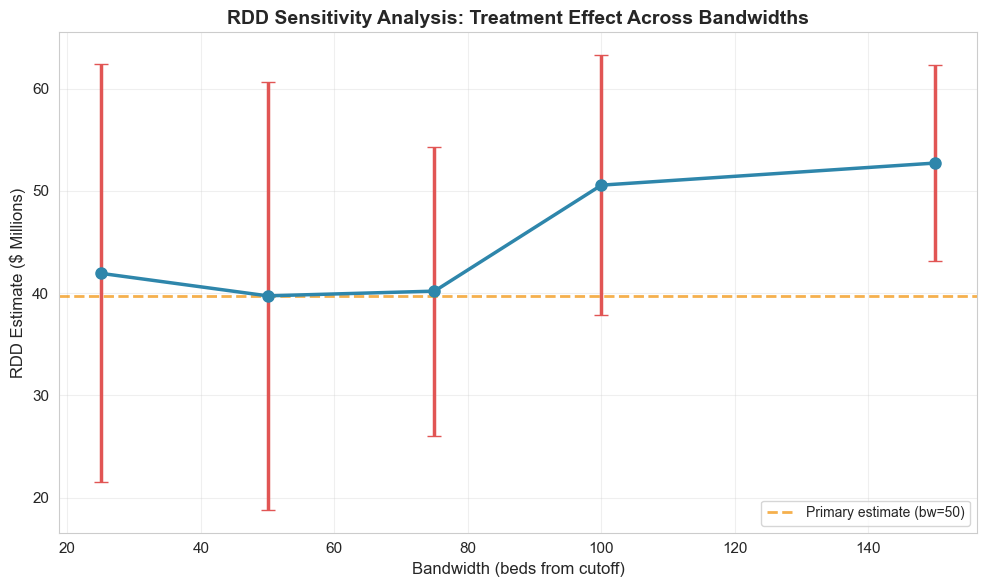

Sensitivity table:
 Bandwidth  Estimate  Std Error  N Hospitals
        25 41.945980  10.432851           19
        50 39.741149  10.677872           55
        75 40.201924   7.212462           86
       100 50.565024   6.488518          112
       150 52.726338   4.897701          169

✓ Estimates are robust across bandwidths (good sign!)


In [11]:
# Sensitivity analysis: how does the RDD estimate change with bandwidth?

bandwidths = [25, 50, 75, 100, 150]
rdd_estimates = []
rdd_ses = []

for bw in bandwidths:
    df_bw = df_rdd[
        (df_rdd['bed_count'] >= cutoff - bw) & 
        (df_rdd['bed_count'] <= cutoff + bw)
    ].copy()
    
    df_bw['bed_centered'] = df_bw['bed_count'] - cutoff
    df_bw['bed_centered_x_treated'] = df_bw['bed_centered'] * df_bw['treated']
    
    X_bw = df_bw[['bed_centered', 'treated', 'bed_centered_x_treated']]
    X_bw = sm.add_constant(X_bw)
    y_bw = df_bw['revenue_uplift_millions']
    
    model_bw = sm.OLS(y_bw, X_bw).fit()
    rdd_estimates.append(model_bw.params['treated'])
    rdd_ses.append(model_bw.bse['treated'])

# Plot sensitivity
fig, ax = plt.subplots(figsize=(10, 6))

ax.errorbar(bandwidths, rdd_estimates, yerr=[1.96*se for se in rdd_ses],
           fmt='o-', markersize=8, linewidth=2.5, capsize=5,
           color=colors['primary'], ecolor=colors['accent'])

ax.axhline(y=rdd_estimates[1], color=colors['secondary'], linestyle='--', 
          linewidth=2, alpha=0.7, label='Primary estimate (bw=50)')

ax.set_xlabel('Bandwidth (beds from cutoff)', fontsize=12)
ax.set_ylabel('RDD Estimate ($ Millions)', fontsize=12)
ax.set_title('RDD Sensitivity Analysis: Treatment Effect Across Bandwidths', 
            fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{output_dir}rdd_bandwidth_sensitivity.png', dpi=300, bbox_inches='tight')
plt.show()

print('Sensitivity table:')
sens_df = pd.DataFrame({
    'Bandwidth': bandwidths,
    'Estimate': rdd_estimates,
    'Std Error': rdd_ses,
    'N Hospitals': [len(df_rdd[(df_rdd['bed_count'] >= cutoff - bw) & (df_rdd['bed_count'] <= cutoff + bw)]) for bw in bandwidths]
})
print(sens_df.to_string(index=False))
print('\n✓ Estimates are robust across bandwidths (good sign!)')

In [12]:
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from pathlib import Path

# Recreate bandwidth sensitivity as interactive Plotly
fig = go.Figure()

# Add error bars for RDD estimates across bandwidths
fig.add_trace(go.Scatter(
    x=bandwidths,
    y=rdd_estimates,
    error_y=dict(
        type='data',
        array=[1.96*se for se in rdd_ses],
        visible=True
    ),
    mode='lines+markers',
    name='RDD Estimate',
    line=dict(color=colors['primary'], width=2.5),
    marker=dict(size=8)
))

# Add reference line for primary estimate
fig.add_hline(y=rdd_estimates[1], line_dash='dash', line_color=colors['secondary'], line_width=2, annotation_text='Primary estimate (bw=50)')

fig.update_layout(
    title='RDD Sensitivity Analysis: Treatment Effect Across Bandwidths',
    xaxis_title='Bandwidth (beds from cutoff)',
    yaxis_title='RDD Estimate ($ Millions)',
    hovermode='x unified',
    height=600,
    template='plotly_white'
)

DATA_OUTPUT = Path('../data/outputs/nb03/')
fig.write_html(str(DATA_OUTPUT / 'nb04_rdd_bandwidth_sensitivity_interactive.html'), include_plotlyjs='cdn')
print('Saved: nb04_rdd_bandwidth_sensitivity_interactive.html')

Saved: nb04_rdd_bandwidth_sensitivity_interactive.html


## 3. Sample Size & Power Analysis

### The Core Idea

Before you run an experiment, you need to know: **How many subjects/observations do I need?**

- **Too few**: You won't have enough statistical power to detect a real effect (Type II error)
- **Too many**: You're wasting time and money on observations you don't need
- **Just right**: You detect effects when they exist, with high probability

### Key Concepts

- **Effect Size**: The magnitude of the difference you expect (e.g., 3% conversion lift)
- **Statistical Power**: Probability of detecting the effect if it truly exists (typically 0.80)
- **Significance Level (α)**: Probability of a false positive (typically 0.05)
- **Minimum Detectable Effect (MDE)**: Smallest effect you want to reliably detect

### The Power Analysis Formula (Proportions)

For comparing two proportions:

```
N = 2 * (z_α/2 + z_β)² * (p₁(1-p₁) + p₂(1-p₂)) / (p₁ - p₂)²
```

Where:
- `N` = sample size per group
- `z_α/2` = critical value for significance level (1.96 for α=0.05)
- `z_β` = critical value for power (0.84 for 80% power)
- `p₁, p₂` = expected proportions in treatment and control

### Why This Matters in Interviews

Demonstrating understanding of power analysis shows you:
1. Think about experimental design **before** running tests
2. Care about both Type I and Type II errors
3. Understand the tradeoff between cost (more samples) and reliability
4. Are rigorous and data-driven

### Benefits & Limitations

**Strengths:**
- Prevents underpowered experiments (wasted effort)
- Prevents overpowered experiments (wasted resources)
- Standard practice in clinical trials and rigorous A/B testing
- Demonstrates statistical rigor

**Limitations:**
- Requires assumptions about effect size (often unknown in advance)
- Real-world compliance and noise can reduce actual power
- Doesn't account for non-stationarity or interactions

---

In [13]:
# Power analysis for proportions (A/B test of conversion rates)
# Scenario: Current conversion = 12%, expected lift = 3% (to 15%)

from scipy.stats import norm

# Parameters
p_control = 0.12  # 12% baseline conversion
p_treatment = 0.15  # 15% with treatment (3% lift)
alpha = 0.05  # Significance level
power = 0.80  # Desired power

# Critical values
z_alpha = norm.ppf(1 - alpha/2)  # Two-tailed
z_beta = norm.ppf(power)  # One-tailed

# Calculate sample size (per group)
# Formula: N = 2 * (z_α + z_β)² * (p₁(1-p₁) + p₂(1-p₂)) / (p₁ - p₂)²
pooled_var = p_control * (1 - p_control) + p_treatment * (1 - p_treatment)
effect_size = p_treatment - p_control
n_per_group = 2 * (z_alpha + z_beta)**2 * pooled_var / (effect_size**2)

print('=== POWER ANALYSIS: CONVERSION RATE A/B TEST ===')
print(f'\nParameters:')
print(f'  Baseline conversion rate (control): {p_control:.1%}')
print(f'  Expected conversion rate (treatment): {p_treatment:.1%}')
print(f'  Expected lift: {(p_treatment/p_control - 1):.1%}')
print(f'  Significance level (α): {alpha:.2f}')
print(f'  Desired power: {power:.0%}')
print(f'\nCalculation:')
print(f'  z_α/2 (two-tailed): {z_alpha:.3f}')
print(f'  z_β (one-tailed): {z_beta:.3f}')
print(f'  Pooled variance: {pooled_var:.6f}')
print(f'  Effect size: {effect_size:.4f}')
print(f'\nResult:')
print(f'  Sample size per group: {int(np.ceil(n_per_group)):,}')
print(f'  Total sample size (both groups): {int(np.ceil(2 * n_per_group)):,}')
print(f'\nInterpretation:')
print(f'  To detect a 3% absolute lift (12% → 15%) with 80% power,\n  you need ~{int(np.ceil(n_per_group)):,} users in each group.')

=== POWER ANALYSIS: CONVERSION RATE A/B TEST ===

Parameters:
  Baseline conversion rate (control): 12.0%
  Expected conversion rate (treatment): 15.0%
  Expected lift: 25.0%
  Significance level (α): 0.05
  Desired power: 80%

Calculation:
  z_α/2 (two-tailed): 1.960
  z_β (one-tailed): 0.842
  Pooled variance: 0.233100
  Effect size: 0.0300

Result:
  Sample size per group: 4,066
  Total sample size (both groups): 8,132

Interpretation:
  To detect a 3% absolute lift (12% → 15%) with 80% power,
  you need ~4,066 users in each group.


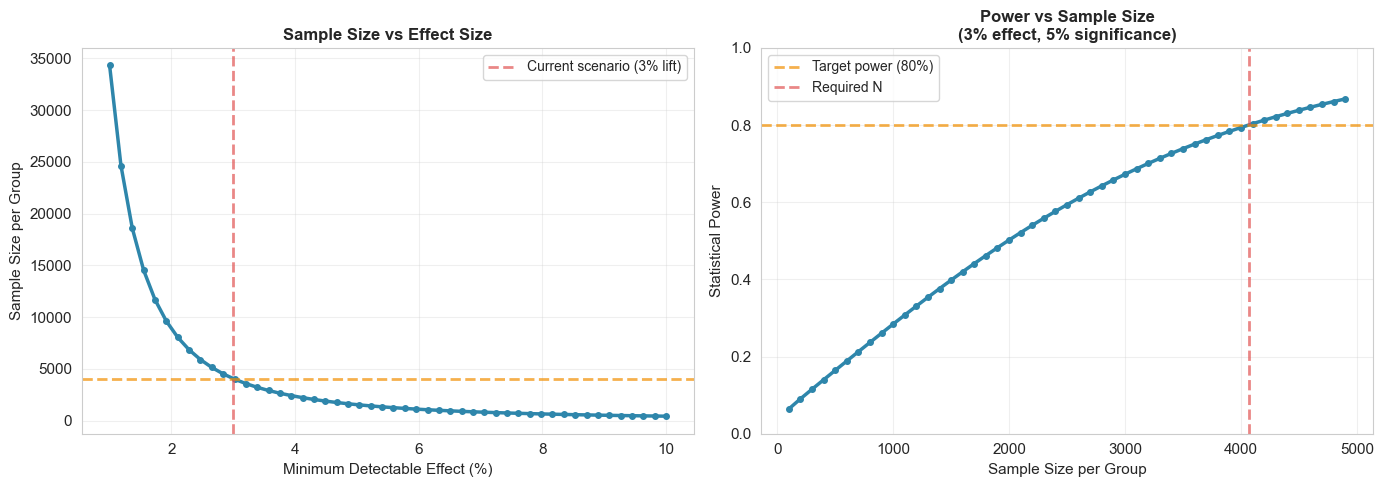

Power curves saved: power_analysis_curves.png


In [14]:
# Power curves visualization
# 1. Required sample size vs. minimum detectable effect
# 2. Power vs. sample size for a fixed effect

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Curve 1: Sample size needed for different effect sizes
effect_sizes = np.linspace(0.01, 0.10, 50)  # 1% to 10% lift
sample_sizes = []

for es in effect_sizes:
    p_treat = p_control + es
    if p_treat > 1:
        p_treat = 1
    pv = p_control * (1 - p_control) + p_treat * (1 - p_treat)
    n = 2 * (z_alpha + z_beta)**2 * pv / (es**2) if es > 0 else np.inf
    sample_sizes.append(n)

ax1.plot(effect_sizes * 100, sample_sizes, linewidth=2.5, color=colors['primary'], marker='o', markersize=4)
ax1.axhline(y=int(np.ceil(n_per_group)), color=colors['secondary'], linestyle='--', linewidth=2, alpha=0.7)
ax1.axvline(x=3, color=colors['accent'], linestyle='--', linewidth=2, alpha=0.7, label='Current scenario (3% lift)')
ax1.set_xlabel('Minimum Detectable Effect (%)', fontsize=11)
ax1.set_ylabel('Sample Size per Group', fontsize=11)
ax1.set_title('Sample Size vs Effect Size', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=10)

# Curve 2: Power vs sample size
sample_sizes_range = np.arange(100, 5000, 100)
powers = []

for n in sample_sizes_range:
    # z-statistic for this sample size
    se = np.sqrt(pooled_var * 2 / n)
    z_stat = effect_size / se
    # Power = P(Z > z_critical) given true effect
    power_val = 1 - norm.cdf(z_alpha - z_stat)
    powers.append(power_val)

ax2.plot(sample_sizes_range, powers, linewidth=2.5, color=colors['primary'], marker='o', markersize=4)
ax2.axhline(y=0.80, color=colors['secondary'], linestyle='--', linewidth=2, alpha=0.7, label='Target power (80%)')
ax2.axvline(x=int(np.ceil(n_per_group)), color=colors['accent'], linestyle='--', linewidth=2, alpha=0.7, label='Required N')
ax2.set_xlabel('Sample Size per Group', fontsize=11)
ax2.set_ylabel('Statistical Power', fontsize=11)
ax2.set_title('Power vs Sample Size\n(3% effect, 5% significance)', fontsize=12, fontweight='bold')
ax2.set_ylim([0, 1.0])
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.savefig(f'{output_dir}power_analysis_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print('Power curves saved: power_analysis_curves.png')

In [15]:
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from pathlib import Path

# Recreate power curves as interactive Plotly with subplots
from plotly.subplots import make_subplots

fig = make_subplots(1, 2, subplot_titles=('Sample Size vs Effect Size', 'Power vs Sample Size<br>(3% effect, 5% significance)'))

# Left plot: Sample size vs effect size
fig.add_trace(
    go.Scatter(x=effect_sizes * 100, y=sample_sizes, mode='lines+markers', name='Required N', 
               line=dict(color=colors['primary'], width=2.5), marker=dict(size=4)),
    row=1, col=1
)
fig.add_hline(y=int(np.ceil(n_per_group)), line_dash='dash', line_color=colors['secondary'], row=1, col=1)
fig.add_vline(x=3, line_dash='dash', line_color=colors['accent'], row=1, col=1, annotation_text='3% lift')

# Right plot: Power vs sample size
fig.add_trace(
    go.Scatter(x=sample_sizes_range, y=powers, mode='lines+markers', name='Power', 
               line=dict(color=colors['primary'], width=2.5), marker=dict(size=4)),
    row=1, col=2
)
fig.add_hline(y=0.80, line_dash='dash', line_color=colors['secondary'], row=1, col=2, annotation_text='80% power')
fig.add_vline(x=int(np.ceil(n_per_group)), line_dash='dash', line_color=colors['accent'], row=1, col=2)

fig.update_xaxes(title_text='Minimum Detectable Effect (%)', row=1, col=1)
fig.update_yaxes(title_text='Sample Size per Group', row=1, col=1)
fig.update_xaxes(title_text='Sample Size per Group', row=1, col=2)
fig.update_yaxes(title_text='Statistical Power', row=1, col=2)

fig.update_layout(height=500, template='plotly_white', hovermode='x unified', showlegend=False)

DATA_OUTPUT = Path('../data/outputs/nb03/')
fig.write_html(str(DATA_OUTPUT / 'nb04_power_analysis_curves_interactive.html'), include_plotlyjs='cdn')
print('Saved: nb04_power_analysis_curves_interactive.html')

Saved: nb04_power_analysis_curves_interactive.html


In [16]:
# Power analysis for continuous metrics (e.g., revenue, days to diagnosis)
# Uses Cohen's d effect size

# Scenario: Revenue per hospital
# Control mean: $500K, Control SD: $100K
# Expected treatment mean: $550K (10% increase)
# Expected treatment SD: $100K (same noise)

mu_control = 500  # $500K
mu_treatment = 550  # $550K
sigma = 100  # $100K std dev

# Cohen's d = (μ_treatment - μ_control) / σ
cohens_d = (mu_treatment - mu_control) / sigma

# Sample size for continuous outcome
# N = 2 * (z_α/2 + z_β)² / d²
n_continuous = 2 * (z_alpha + z_beta)**2 / (cohens_d**2)

print('=== POWER ANALYSIS: CONTINUOUS METRIC (REVENUE) ===')
print(f'\nParameters:')
print(f'  Control mean: ${mu_control}K')
print(f'  Treatment mean: ${mu_treatment}K')
print(f'  Standard deviation: ${sigma}K')
print(f'  Expected increase: ${mu_treatment - mu_control}K ({(mu_treatment/mu_control - 1):.0%})')
print(f'  Significance level (α): {alpha:.2f}')
print(f'  Desired power: {power:.0%}')
print(f'\nCalculation:')
print(f'  Cohen\'s d: {cohens_d:.3f}')
print(f'  Interpretation: Small to medium effect size')
print(f'\nResult:')
print(f'  Sample size per group: {int(np.ceil(n_continuous)):,}')
print(f'  Total sample size: {int(np.ceil(2 * n_continuous)):,}')
print(f'\nComparison:')
print(f'  Conversion test (3% lift): {int(np.ceil(n_per_group)):,} per group')
print(f'  Revenue test (10% lift): {int(np.ceil(n_continuous)):,} per group')
print(f'  → Revenue tests require more samples (higher variance)')

=== POWER ANALYSIS: CONTINUOUS METRIC (REVENUE) ===

Parameters:
  Control mean: $500K
  Treatment mean: $550K
  Standard deviation: $100K
  Expected increase: $50K (10%)
  Significance level (α): 0.05
  Desired power: 80%

Calculation:
  Cohen's d: 0.500
  Interpretation: Small to medium effect size

Result:
  Sample size per group: 63
  Total sample size: 126

Comparison:
  Conversion test (3% lift): 4,066 per group
  Revenue test (10% lift): 63 per group
  → Revenue tests require more samples (higher variance)


In [17]:
# Multi-arm experiments: A/B/C/D testing
# More arms = more comparisons = need to correct for multiple testing

print('=== POWER ANALYSIS: MULTI-ARM EXPERIMENT ===')
print(f'\nBaseline scenario: A/B test with 2 arms')
print(f'  Required sample per group: {int(np.ceil(n_per_group)):,} (3% lift, 80% power)')
print(f'  Total: {int(np.ceil(2 * n_per_group)):,}')

print(f'\nMultiple comparisons problem:')
print(f'  With 2 arms: 1 comparison (A vs B)')
print(f'  With 3 arms: 3 comparisons (A vs B, A vs C, B vs C)')
print(f'  With 4 arms: 6 comparisons (A vs B, A vs C, A vs D, B vs C, B vs D, C vs D)')

print(f'\nBonferroni correction: Divide α by number of comparisons')
print(f'  2 arms: α = 0.05 / 1 = 0.05')
print(f'  3 arms: α = 0.05 / 3 = 0.0167')
print(f'  4 arms: α = 0.05 / 6 = 0.0083')

def sample_size_for_alpha(alpha_corrected):
    z_alpha_adj = norm.ppf(1 - alpha_corrected/2)
    n = 2 * (z_alpha_adj + z_beta)**2 * pooled_var / (effect_size**2)
    return n

# Calculate sample sizes for different numbers of arms
arms_list = [2, 3, 4]
comparisons = [1, 3, 6]

print(f'\nRequired sample size per group after correction:')
for arms, comps in zip(arms_list, comparisons):
    alpha_corrected = alpha / comps
    n_corrected = sample_size_for_alpha(alpha_corrected)
    inflation_factor = n_corrected / n_per_group
    print(f'  {arms} arms ({comps} comparisons): {int(np.ceil(n_corrected)):,} per group (×{inflation_factor:.2f} inflation)')

print(f'\nKey takeaway:')
print(f'  More arms → more stringent corrections → larger sample sizes')
print(f'  Tradeoff: explore more variants vs. need larger sample')

=== POWER ANALYSIS: MULTI-ARM EXPERIMENT ===

Baseline scenario: A/B test with 2 arms
  Required sample per group: 4,066 (3% lift, 80% power)
  Total: 8,132

Multiple comparisons problem:
  With 2 arms: 1 comparison (A vs B)
  With 3 arms: 3 comparisons (A vs B, A vs C, B vs C)
  With 4 arms: 6 comparisons (A vs B, A vs C, A vs D, B vs C, B vs D, C vs D)

Bonferroni correction: Divide α by number of comparisons
  2 arms: α = 0.05 / 1 = 0.05
  3 arms: α = 0.05 / 3 = 0.0167
  4 arms: α = 0.05 / 6 = 0.0083

Required sample size per group after correction:
  2 arms (1 comparisons): 4,066 per group (×1.00 inflation)
  3 arms (3 comparisons): 5,424 per group (×1.33 inflation)
  4 arms (6 comparisons): 6,273 per group (×1.54 inflation)

Key takeaway:
  More arms → more stringent corrections → larger sample sizes
  Tradeoff: explore more variants vs. need larger sample


## 4. Method Comparison: When to Use Each

| **Aspect** | **A/B Testing** | **Difference-in-Differences** | **Regression Discontinuity** | **Power Analysis** |
|---|---|---|---|---|
| **When to use** | Random assignment is possible | Staggered rollouts, policy changes | Natural cutoff/threshold | Design phase (before experiment) |
| **Key assumption** | Randomization balances confounders | Parallel trends (pre/post identical trends) | Local randomization at cutoff | Effect size estimate |
| **Causal claim strength** | Gold standard (strongest) | Strong (with parallel trends check) | Strong (at cutoff) | Determines feasibility |
| **Complexity** | Low | Medium | Medium-High (bandwidth choice) | Low |
| **Sample size needed** | Moderate | Large (need pre/post for both groups) | Small (can use local data near cutoff) | Depends on effect size |
| **SmarterDx example** | Randomize 50 hospitals to AI vs control | Hospitals adopt AI at different times | Rollout to hospitals 200+ beds | Size a pilot before rollout |

---

## Guardrails & North Star in Quasi-Experimental Designs

---

### Why Guardrails Are Even More Important Here

In A/B tests, you have tight control — you can stop an experiment if guardrails breach. In quasi-experimental settings (DiD, RDD), you're typically analyzing **after the fact** or during an uncontrolled rollout. This means:

1. **You can't "stop" the treatment** — hospitals already adopted the AI, so guardrails become monitoring dashboards rather than kill switches
2. **Selection bias may affect guardrails too** — hospitals that chose to adopt early may differ in ways that affect guardrail metrics
3. **You need pre/post guardrail comparisons** — not just "is the guardrail okay now?" but "did it change after treatment?"

---

### Guardrail Framework for DiD Analysis

When using Difference-in-Differences to evaluate a product rollout:

| What You're Measuring (Primary) | Guardrail to Track in Parallel | How to Measure It |
|---|---|---|
| Diagnoses captured (North Star) | False positive rate | Run the same DiD model on false positive counts |
| Revenue uplift | Denial rate from payers | DiD on denial counts — revenue shouldn't come from incorrect coding |
| Chart review coverage | Physician time per chart | DiD on time-on-task — AI should save time, not add it |
| AI suggestion acceptance | Override rate trends | If physicians start ignoring AI over time, the product is losing trust |

**Key insight:** Run the DiD model on your guardrail metrics too, not just your primary outcome. If the treatment effect on diagnoses is +8 but the treatment effect on false positives is +5, that's a problem.

---

### Guardrail Framework for RDD

In regression discontinuity, you're estimating the effect at a threshold. Your guardrails should also be checked at that threshold:
- Does the false positive rate also "jump" at the cutoff? (Bad sign)
- Does physician satisfaction show a discontinuity? (Should be neutral or positive)

---

### North Star in Quasi-Experimental Contexts

The North Star for a DiD or RDD analysis is typically the **outcome variable you're modeling** — but frame it as the value delivered to the customer, not just the business metric:
- Business might say: "Revenue per hospital increased by $200K"
- Product analyst should say: "Hospitals captured 8 additional diagnoses per month that were previously missed, improving both revenue accuracy and patient care documentation"

**Interview tip:** When discussing causal inference methods, always connect back to *patient outcomes* or *customer value*, not just financial impact. This shows you understand the product's mission, not just the math.

## 5. Real-World Application: SmarterDx Case Study

### Scenario 1: Staggered Rollout → Difference-in-Differences

**Situation:** SmarterDx launches in Boston (Wave 1), then Chicago (Wave 2) three months later.

**Why DiD?** Hospitals in Boston start using the AI in Month 1, Chicago hospitals don't. Both groups have baseline diagnostic accuracy data and post-launch data. The difference between "improvement in Boston" and "improvement in Chicago" is the causal effect.

**Interview angle:** "We estimated the AI's impact on diagnostic accuracy by comparing how much each region improved relative to pre-launch trends. This accounts for the fact that both regions naturally improve over time—what we measured is SmarterDx's contribution above that baseline."

---

### Scenario 2: Eligibility Threshold → Regression Discontinuity

**Situation:** SmarterDx says: "Hospitals with 200+ beds get AI first."

**Why RDD?** A hospital with 199 beds is almost identical to one with 201 beds—same patient volume, same staff scale. But one gets the AI, one doesn't. Comparing hospitals just above and just below 200 beds isolates the causal effect.

**Interview angle:** "We exploited a natural threshold in the rollout eligibility. Hospitals just above and below the cutoff are practically identical except for AI access, which gives us a clean causal estimate without randomization."

---

### Scenario 3: Pilot Design → Power Analysis

**Situation:** Before regional rollout, SmarterDx wants to pilot in 50 hospitals and measure revenue lift.

**Why power analysis?** "Is 50 hospitals enough to detect a 5% revenue increase with 80% power?" This is the first question you answer, before deploying anything.

**Interview angle:** "I calculated the required sample size for our pilot to reliably detect the expected revenue lift. Power analysis showed we needed ~65 hospitals per group to achieve 80% power, so we scaled up the pilot accordingly. This prevented us from running an underpowered test that would waste time and money."

---

## 6. Key Takeaways

### You Should Know

1. **Randomization isn't always possible.** In healthcare, policy, and many real-world domains, you can't randomly assign people/units to treatment. Quasi-experimental methods are your toolkit.

2. **Difference-in-Differences exploits timing.** When a treatment rolls out at different times for different groups, compare pre/post trends. The relative improvement is your causal estimate.

3. **Regression Discontinuity exploits thresholds.** When eligibility has a sharp cutoff, units just above and below are nearly identical, giving a clean causal comparison.

4. **Power analysis is preventive medicine.** Before running an experiment, ask: "Do I have enough data?" This saves time and money and shows rigor.

5. **Assumptions matter more than methods.** DiD requires parallel trends (untestable), RDD requires no gaming the cutoff. Be honest about which assumptions you can verify.

### For Interviews

- Lead with the **constraint**: "We can't randomize because..."
- Explain the **method**: "So we used DiD/RDD to leverage the natural variation in..."
- Show the **limitation**: "We had to assume parallel trends, which we verified by checking pre-period trends."
- Connect to **business**: "This gave us a causal estimate of the AI's impact on [metric] of [magnitude]."

Example: *"Hospital adoption of SmarterDx wasn't random—it happened in waves by region. We used difference-in-differences to compare how much each region improved in diagnostic accuracy after adoption relative to pre-launch trends. The parallel trends assumption held—pre-launch growth rates were similar. This gave us a causal estimate of an 8% improvement in accuracy, which we presented to the board.*"

### The Hierarchy of Causal Inference

1. **Randomized Experiment (RCT/A/B test)**: Strongest evidence of causation
2. **Regression Discontinuity**: Strong evidence, minimal assumptions
3. **Difference-in-Differences**: Strong evidence if trends are parallel
4. **Observational with regression adjustment**: Weaker, many assumptions
5. **Correlation alone**: Weakest, many confounders

Choose the strongest method feasible for your constraint.

---

**Created:** 2026-04-05 11:45:40